# 1. Curvature in 2D (curves)

We start with a simple function:

$$
y = \sin(x)
$$

---

### (a) First derivative (slope)

$$
\frac{dy}{dx} = y'(x) = \cos(x)
$$

This gives the **slope of the tangent line** at each point.

---

### (b) Second derivative (rate of slope change)

$$
\frac{d^2y}{dx^2} = y''(x) = -\sin(x)
$$

This describes how the slope itself is changing — i.e. **how much the curve bends**.

---

### (c) General curvature formula for a 2D curve

The curvature $\kappa(x)$ measures how “bent” the curve is at a point.  

For a curve $y(x)$:

$$
\kappa(x) = \frac{|y''(x)|}{\left( 1 + (y'(x))^2 \right)^{3/2}}
$$

- Numerator $|y''|$: how much the slope is changing  
- Denominator $(1+y'^2)^{3/2}$: normalization so that curvature is scale-independent  

If the curve is **straight** → $\kappa = 0$.  
If the curve bends sharply → $\kappa$ is large.

For $y=\sin(x)$:

$$
\kappa(x) = \frac{|-\sin(x)|}{\big(1 + \cos^2(x)\big)^{3/2}}
$$

---

# 2. Curvature of Surfaces in 3D

Now we move to a **surface**:

$$
z = f(x,y) = x^2 - y^2
$$

This is a **saddle surface**.

---

### (a) First derivatives (gradient)

$$
f_x = \frac{\partial f}{\partial x} = 2x, \quad
f_y = \frac{\partial f}{\partial y} = -2y
$$

---

### (b) Second derivatives (Hessian matrix)

The **Hessian** of $f(x,y)$ is:

$$
H_f(x,y) =
\begin{bmatrix}
f_{xx} & f_{xy} \\
f_{yx} & f_{yy}
\end{bmatrix}
$$

For this function:

$$
f_{xx} = 2, \quad f_{yy} = -2, \quad f_{xy} = f_{yx} = 0
$$

---

### (c) First Fundamental Form

The metric of the surface measures distances on it:

$$
E = 1 + f_x^2, \quad 
F = f_x f_y, \quad 
G = 1 + f_y^2
$$

---

### (d) Second Fundamental Form

These coefficients capture how the surface bends:

$$
L = \frac{f_{xx}}{\sqrt{1+f_x^2+f_y^2}}, \quad
M = \frac{f_{xy}}{\sqrt{1+f_x^2+f_y^2}}, \quad
N = \frac{f_{yy}}{\sqrt{1+f_x^2+f_y^2}}
$$

---

### (e) Gaussian curvature (intrinsic curvature)

Gaussian curvature $K$ is the product of the two **principal curvatures** $(\kappa_1, \kappa_2)$:

$$
K = \kappa_1 \kappa_2
$$

Formula in terms of derivatives:

$$
K = \frac{f_{xx} f_{yy} - f_{xy}^2}{\big(1 + f_x^2 + f_y^2\big)^2}
$$

For this function:

$$
K = \frac{(2)(-2) - 0}{(1 + (2x)^2 + (-2y)^2)^2}
= \frac{-4}{(1+4x^2+4y^2)^2}
$$

- Negative everywhere → **saddle surface** (hyperbolic curvature).

---

### (f) Mean curvature (average curvature)

Mean curvature $H$ is the **average of the principal curvatures**:

$$
H = \frac{\kappa_1 + \kappa_2}{2}
$$

Formula in terms of derivatives:

$$
H = \frac{ (1+f_y^2)f_{xx} - 2f_x f_y f_{xy} + (1+f_x^2)f_{yy} }
{2 \big(1+f_x^2+f_y^2\big)^{3/2}}
$$

For this function:

$$
H = \frac{ (1+(-2y)^2)(2) + (1+(2x)^2)(-2) }
{2 \big(1+(2x)^2+(-2y)^2\big)^{3/2}}
$$

Simplify:

$$
H = \frac{ 2(1+4y^2) - 2(1+4x^2) }{2(1+4x^2+4y^2)^{3/2}}
= \frac{4(y^2 - x^2)}{(1+4x^2+4y^2)^{3/2}}
$$

---

# 3. Geometric Intuition

- **2D curvature**: measures how fast the tangent angle is changing with respect to arc length.  
- **Gaussian curvature $K$**:  
  - $K > 0$: sphere-like (elliptic)  
  - $K < 0$: saddle-like (hyperbolic)  
  - $K = 0$: flat direction present (cylinder, plane)  
- **Mean curvature $H$**: average bending.  
  - Minimal surfaces (like soap films) satisfy $H = 0$.

---

✅ In summary:
- 2D case → curvature of $\sin(x)$  
- 3D case → saddle surface with $K < 0$ and variable $H$  


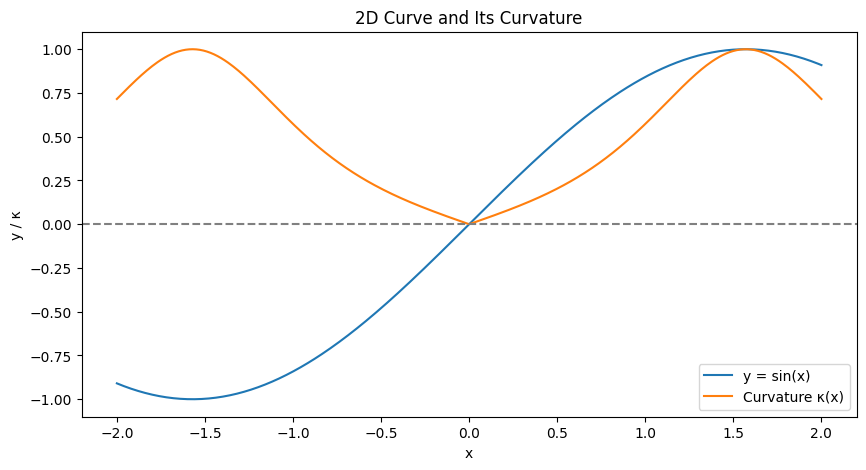

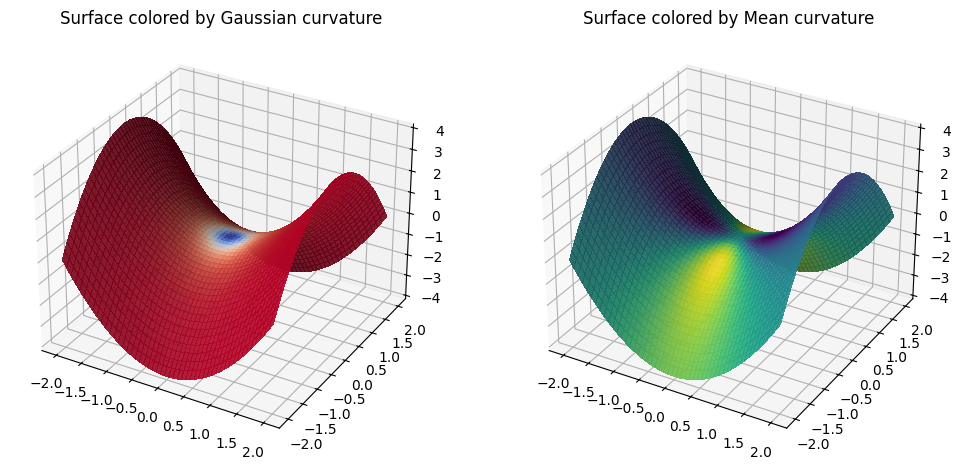

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# 1. Curvature in 2D (simple function)
# ----------------------------
x = np.linspace(-2, 2, 400)
y = np.sin(x)

# First derivative (slope)
dy_dx = np.cos(x)

# Second derivative (curvature measure)
d2y_dx2 = -np.sin(x)

# Curvature formula for 2D curve: κ = |y''| / (1 + (y')^2)^(3/2)
curvature = np.abs(d2y_dx2) / (1 + dy_dx**2) ** 1.5

plt.figure(figsize=(10, 5))
plt.plot(x, y, label="y = sin(x)")
plt.plot(x, curvature, label="Curvature κ(x)")
plt.axhline(0, color="gray", linestyle="--")
plt.legend()
plt.title("2D Curve and Its Curvature")
plt.xlabel("x")
plt.ylabel("y / κ")
plt.show()


# ----------------------------
# 2. Curvature intuition on a 3D surface (Hessian-based)
# ----------------------------
def f(x, y):
    return x**2 - y**2  # Saddle surface

# Grid
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# First derivatives
fx = 2 * X
fy = -2 * Y

# Second derivatives (Hessian components)
fxx = 2 * np.ones_like(X)
fyy = -2 * np.ones_like(Y)
fxy = np.zeros_like(X)

# Gaussian curvature K = (fxx*fyy - fxy^2) / (1 + fx^2 + fy^2)^2
K = (fxx * fyy - fxy**2) / (1 + fx**2 + fy**2)**2

# Mean curvature H = ( (1+fy^2)*fxx - 2*fx*fy*fxy + (1+fx^2)*fyy ) / (2*(1+fx**2+fy**2)^(3/2))
H = ((1+fy**2)*fxx - 2*fx*fy*fxy + (1+fx**2)*fyy) / (2*(1+fx**2+fy**2)**1.5)

# Plot surface colored by Gaussian curvature
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(X, Y, Z, facecolors=plt.cm.coolwarm((K - K.min())/(K.max()-K.min())),
                rstride=1, cstride=1, linewidth=0, antialiased=False, alpha=0.9)
ax.set_title("Surface colored by Gaussian curvature")

# Plot surface colored by Mean curvature
ax2 = fig.add_subplot(122, projection="3d")
ax2.plot_surface(X, Y, Z, facecolors=plt.cm.viridis((H - H.min())/(H.max()-H.min())),
                 rstride=1, cstride=1, linewidth=0, antialiased=False, alpha=0.9)
ax2.set_title("Surface colored by Mean curvature")

plt.show()
